<a href="https://colab.research.google.com/github/Aleem-mja/DeepLearning-Project-SLIIT-SE4050/blob/IT22313966/IMDB_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# -------------------------------
# 1) Imports, seeds, and globals
# -------------------------------
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import os

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Hyperparameters / globals
MAX_FEATURES = 10000   # number of words to keep (most frequent)
MAXLEN = 500           # cut texts after this number of words (among top MAX_FEATURES)
EMBED_DIM = 128
RNN_UNITS = 64
BATCH_SIZE = 128
EPOCHS = 10
VAL_SAMPLES = 5000     # size of validation set taken from training set
MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

In [2]:
# -----------------------------------------
# 2) Data loading and preprocessing (Keras)
# -----------------------------------------
print("Loading IMDB dataset (integer-encoded reviews)...")
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=MAX_FEATURES)

# Pad sequences so all inputs have the same length
x_train = pad_sequences(x_train, maxlen=MAXLEN)
x_test  = pad_sequences(x_test,  maxlen=MAXLEN)

print("Shapes after padding:")
print(f"  x_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"  x_test:  {x_test.shape},  y_test:  {y_test.shape}")

# Create validation set from the end of training set
x_val = x_train[-VAL_SAMPLES:]
y_val = y_train[-VAL_SAMPLES:]
x_train = x_train[:-VAL_SAMPLES]
y_train = y_train[:-VAL_SAMPLES]

print("Shapes after creating validation set:")
print(f"  x_train: {x_train.shape}, x_val: {x_val.shape}, x_test: {x_test.shape}")


Loading IMDB dataset (integer-encoded reviews)...
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Shapes after padding:
  x_train: (25000, 500), y_train: (25000,)
  x_test:  (25000, 500),  y_test:  (25000,)
Shapes after creating validation set:
  x_train: (20000, 500), x_val: (5000, 500), x_test: (25000, 500)


In [3]:
# -----------------------------------------
# 3) Model building (function for reuse)
# -----------------------------------------
def build_rnn_model(max_features=MAX_FEATURES, embed_dim=EMBED_DIM, rnn_units=RNN_UNITS, maxlen=MAXLEN, dropout_rate=0.5):
    """
    Build and return a Sequential RNN model:
      Embedding -> SimpleRNN -> SimpleRNN -> Dropout -> Dense(sigmoid)
    """
    model = Sequential([
        Embedding(max_features, embed_dim, input_length=maxlen),
        SimpleRNN(rnn_units, return_sequences=True),
        SimpleRNN(rnn_units),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')
    ])
    return model

# Build and compile
print("Building model...")
model = build_rnn_model()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Building model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [4]:
# ---------------------------
# 4) Train the model
# ---------------------------
print("Training the model...")
history = model.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val, y_val),
    verbose=1
)

# Save the trained model for later use
model_path = os.path.join(MODEL_DIR, "imdb_rnn_model.h5")
model.save(model_path)
print(f"Saved model to: {model_path}")


Training the model...
Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 86s 526ms/step - accuracy: 0.5265 - loss: 0.7081 - val_accuracy: 0.5848 - val_loss: 0.7741
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 75s 479ms/step - accuracy: 0.7076 - loss: 0.5798 - val_accuracy: 0.7972 - val_loss: 0.4574
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 83s 485ms/step - accuracy: 0.8781 - loss: 0.3042 - val_accuracy: 0.7676 - val_loss: 0.5732
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 77s 489ms/step - accuracy: 0.9609 - loss: 0.1143 - val_accuracy: 0.6764 - val_loss: 0.9435
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 76s 481ms/step - accuracy: 0.9765 - loss: 0.0656 - val_accuracy: 0.7380 - val_loss: 0.9004
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 76s 483ms/step - accuracy: 0.9862 - loss: 0.0389 - val_accuracy: 0.7004 - val_loss: 1.1146
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 77s 491ms/step - accuracy: 0.9897 - loss: 0.0300 - val_accuracy: 0.7072 - val_loss: 1.2039
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 83s 528ms/step - accu

Saved model to: models/imdb_rnn_model.h5


In [5]:
# -----------------------------------
# 5) Evaluate on test data & metrics
# -----------------------------------
print("Predicting on test set...")
y_pred_prob = model.predict(x_test, batch_size=BATCH_SIZE)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print(f"Test Accuracy : {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall   : {recall:.4f}")
print(f"Test F1 Score : {f1:.4f}")


Predicting on test set...
196/196 ━━━━━━━━━━━━━━━━━━━━ 26s 130ms/step
Test Accuracy : 0.7168
Test Precision: 0.6963
Test Recall   : 0.7689
Test F1 Score : 0.7308


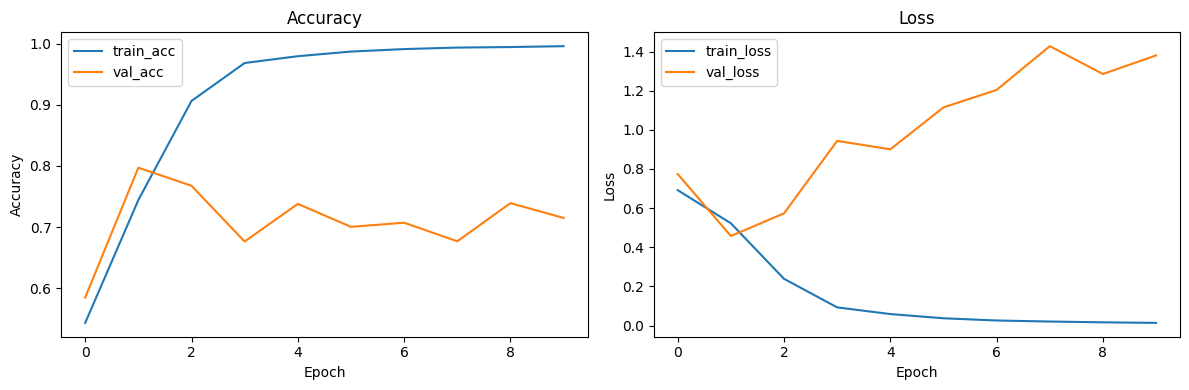

In [6]:
# -----------------------------------
# 6) Plot training & validation curves
# -----------------------------------
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()
